<a href="https://colab.research.google.com/github/IsaacFigNewton/Multiplexed-Hypergraph-Visualizer/blob/main/DAG_to_Hypergraph_to_Power_Diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classes

## PartitionTreeBuilder

In [8]:
"""
partition_tree_builder.py

Refactors the original functional code into a small, testable class with:
- Clear method boundaries
- Type hints
- Docstrings and inline comments
- A simple public API

Core idea:
1) Walk a directed graph from a root and collect "descendant sets" as frozensets.
2) Build a recursive partition tree from those sets by repeatedly splitting the
   most-overlapping pair into (A\C, B\C, C), where C = A∩B.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, FrozenSet, Iterable, Optional, Set, Tuple

import networkx as nx


PartitionTree = Dict[FrozenSet[Any], "PartitionTree"]

@dataclass(frozen=True)
class PartitionTreeBuilder:
    """
    Builds a partition tree from descendant sets derived from a directed graph.

    Public usage patterns:
        builder = PartitionTreeBuilder(G)

        # 1) Build sets from a root, then compute the tree
        sets, descendants = builder.to_sets(root)
        tree = builder.get_partition_tree(sets)

        # 2) Convenience: do everything in one call
        tree = builder.build_from_root(root)

    Notes:
    - The graph is treated as a rooted *reachability* structure via successors().
    - The algorithms below assume the reachable subgraph from `root` is a DAG or,
      at minimum, does not contain cycles reachable from the root. If cycles exist,
      a recursion loop may occur.
    """

    graph: nx.DiGraph

    def build(self) -> PartitionTree:
        """
        Convenience method: compute descendant sets from `root` and build the
        corresponding partition tree.

        Args:
            root: The root node to start from.

        Returns:
            A nested dictionary representing the partition tree.
        """
        roots = [
            n for n in self.graph.nodes()
            if self.graph.predecessors(n)
        ]
        root_sets = [self.to_sets(root)[0] for root in roots]
        sets = set().union(*root_sets)
        # remove the root set
        # sets = sets - {frozenset(self.graph.nodes())}
        # print(sets)
        return self.get_partition_tree(sets)

    def to_sets(self, root: Any) -> Tuple[Set[FrozenSet[Any]], Set[Any]]:
        """
        Convert the reachable subgraph under `root` into a collection of frozensets.

        For every node `n` reachable from `root`, we compute the set of descendants
        of `n` including itself, and add that as a frozenset to the returned set.

        This mirrors the original behavior:
          - `child_sets` is the union of all descendant-sets from children
          - plus the descendant-set for the current `root`.

        Args:
            root: Node to start the recursion.

        Returns:
            (child_sets, all_descendants)
            - child_sets: set of frozensets, each representing a descendant set
            - all_descendants: the (mutable) set of descendants of `root` including itself
        """
        children = list(self.graph.successors(root))

        # Collect all descendant-sets contributed by children.
        child_sets: Set[FrozenSet[Any]] = set()

        # This node is always part of its own descendant set.
        all_descendants: Set[Any] = {root}

        for child in children:
            # Recursively compute:
            # - all sets found under the child
            # - the child's full descendant set
            new_child_sets, descendants = self.to_sets(child)

            # Merge results into our running aggregates.
            child_sets.update(new_child_sets)
            all_descendants.update(descendants)

        # Add the descendant set for this root itself.
        child_sets.add(frozenset(all_descendants))

        return child_sets, all_descendants

    def get_partition_tree(self, sets: Set[FrozenSet[Any]]) -> PartitionTree:
        """
        Recursively build a partition tree from a set of frozensets.

        Algorithm (same as original):
          - Base case: 0 or 1 sets -> return empty subtree {}
          - Find the pair (A, B) with maximum overlap |A∩B|
          - Define:
                C  = A ∩ B
                A1 = A - C
                B1 = B - C
            Then recurse on each non-empty partition using subsets restricted
            to that partition's elements.

        Args:
            sets: A set of frozensets to partition.

        Returns:
            Nested dict mapping each partition (as a frozenset) to its subtree.
        """
        if len(sets) <= 1:
            return {}

        pair = self.get_max_overlapping_pair(sets)
        if pair is None:
            # Defensive: should only happen if `sets` is empty or malformed.
            return {}

        A, B = pair
        C = A.intersection(B)
        partitions = {
            A: A - C,
            B: B - C,
            C: C
        }

        # Build children for each non-empty partition.
        tree: PartitionTree = {}
        for key, partition in partitions.items():
            if not partition:
                continue
            # key = frozenset(partition)
            tree[partition] = self.get_partition_tree(self.get_subsets(partition, sets))
        return tree

    def get_max_overlapping_pair(
        self, sets: Set[FrozenSet[Any]]
    ) -> Optional[Tuple[FrozenSet[Any], FrozenSet[Any]]]:
        """
        Return the pair of sets with the maximum intersection size.

        Args:
            sets: Set of frozensets to compare.

        Returns:
            (A, B) maximizing |A∩B|, or None if fewer than 2 sets are provided.
        """
        if len(sets) < 2:
            return None

        best_pair: Optional[Tuple[FrozenSet[Any], FrozenSet[Any]]] = None
        best_overlap = -1

        # sets_list = sorted(list(sets), key=lambda x: len(x), reverse=True)
        sets_list = list(sets)

        # Brute force O(n^2) over all pairs.
        for i in range(len(sets_list)):
            for j in range(i + 1, len(sets_list)):
                A, B = sets_list[i], sets_list[j]
                overlap = len(A & B)

                if overlap > best_overlap:
                    best_overlap = overlap
                    best_pair = (A, B)


        return best_pair

    def get_subsets(
        self, seed: Iterable[Any], sets: Set[FrozenSet[Any]]
    ) -> Set[FrozenSet[Any]]:
        """
        Filter `sets` down to only those frozensets that are subsets of `seed`.

        Args:
            seed: Elements defining the universe to keep.
            sets: Candidate frozensets.

        Returns:
            All s in `sets` such that s ⊆ seed.
        """
        seed_set = set(seed)
        return {s for s in sets if set(s).issubset(seed_set)}

<>:13: SyntaxWarning: invalid escape sequence '\C'
<>:13: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_21640/1184633948.py:13: SyntaxWarning: invalid escape sequence '\C'
  most-overlapping pair into (A\C, B\C, C), where C = A∩B.


## RecursivePowerDiagram

In [19]:
"""
Recursive (hierarchical) Laguerre / power diagram demo.

This module builds *area-constrained* power diagrams (a.k.a. Laguerre diagrams)
inside an arbitrary convex polygonal region, then recursively subdivides each
cell according to a user-provided hierarchy.

Key ideas
---------
1) **Power diagram cell construction**:
   Each cell is computed as an intersection of half-planes derived from the
   Laguerre distance inequality between sites i and j.

2) **Area targeting via weight fitting**:
   Laguerre weights are iteratively adjusted so each cell's area matches a
   target area (up to tolerance).

3) **Lloyd-style relaxation**:
   With weights fitted, sites are moved toward their cell centroids to improve
   cell quality (damped Lloyd steps), while maintaining area constraints via
   refitting.

4) **Hierarchical field coloring**:
   Per-level siblings are colored consistently using a centroid->RGB mapping
   that is *normalized by the current parent region's bounding box*. This keeps
   colors stable within each subtree, rather than shifting as the global domain
   changes.

Notes / assumptions
-------------------
- Regions are treated as convex polygons. The clipping method assumes convexity.
- Degenerate / empty cells can occur during fitting; we resample sites as needed.
- Coordinates are assumed 2D and stored as float numpy arrays of shape (N, 2).
"""

from __future__ import annotations

import math
from typing import Iterable

import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# Coloring
# =============================================================================

class CentroidColoring:
    """
    Map 2D centroids to RGB by lifting to 3D, rotating, and normalizing.

    This is a lightweight "field coloring" that produces visually distinct but
    spatially coherent colors (nearby centroids have related colors).

    Pipeline
    --------
    1) Normalize centroid (x, y) into [-1, 1] using a provided domain bbox.
    2) Lift to 3D by defining a simple z = f(x, y). (Here: z = 0.5*(x+y))
    3) Apply a 3D rotation (acts like choosing a projection).
    4) Normalize rotated coordinates to [0, 1] to obtain an RGB triplet.

    Parameters that matter
    ----------------------
    - `domain_bbox`: controls how normalization behaves. If you pass the parent
      region bbox (hierarchical use case), siblings share a consistent palette.
    - `angles`: rotation angles (radians) about x/y/z. Different angles yield
      different "palettes" while preserving coherence.

    Returned values
    ---------------
    - RGB values in [0, 1], shape (K, 3).
    """

    @staticmethod
    def _rotation_matrix(ax: float, ay: float, az: float) -> np.ndarray:
        """Create a 3D rotation matrix from Euler angles (x then y then z)."""
        cx, sx = math.cos(ax), math.sin(ax)
        cy, sy = math.cos(ay), math.sin(ay)
        cz, sz = math.cos(az), math.sin(az)

        Rx = np.array([[1, 0, 0],
                       [0, cx, -sx],
                       [0, sx, cx]], dtype=float)
        Ry = np.array([[cy, 0, sy],
                       [0, 1, 0],
                       [-sy, 0, cy]], dtype=float)
        Rz = np.array([[cz, -sz, 0],
                       [sz,  cz, 0],
                       [0,   0,  1]], dtype=float)

        # Apply Rx first, then Ry, then Rz (right-multiplication on column vectors)
        return Rz @ Ry @ Rx

    @staticmethod
    def centroids_to_rgb(
        centroids_xy: np.ndarray,
        domain_bbox: tuple[float, float, float, float],
        *,
        angles: tuple[float, float, float] = (0.9, 0.6, 0.2),
        eps: float = 1e-12,
    ) -> np.ndarray:
        """
        Convert centroid coordinates into RGB colors.

        Parameters
        ----------
        centroids_xy:
            Array of shape (K, 2).
        domain_bbox:
            (xmin, xmax, ymin, ymax) used to normalize x and y into [-1, 1].
        angles:
            Euler rotation angles (ax, ay, az) in radians.
        eps:
            Numerical stabilizer for degenerate bounding boxes.

        Returns
        -------
        np.ndarray:
            Array of shape (K, 3) with values clamped to [0, 1].
        """
        xmin, xmax, ymin, ymax = domain_bbox
        centroids_xy = np.asarray(centroids_xy, dtype=float)

        x = centroids_xy[:, 0]
        y = centroids_xy[:, 1]

        # Normalize to [-1, 1] within bbox
        xn = 2.0 * (x - xmin) / max(xmax - xmin, eps) - 1.0
        yn = 2.0 * (y - ymin) / max(ymax - ymin, eps) - 1.0

        # Lift to 3D (simple plane field)
        zn = 0.5 * (xn + yn)

        P = np.stack([xn, yn, zn], axis=1)  # (K, 3)

        # Rotate in 3D, then normalize to [0, 1] channel-wise
        R = CentroidColoring._rotation_matrix(*angles)
        Q = (R @ P.T).T  # (K, 3)

        qmin = Q.min(axis=0)
        qmax = Q.max(axis=0)
        rgb = (Q - qmin) / (qmax - qmin + eps)
        return np.clip(rgb, 0.0, 1.0)


class HierarchicalFieldColorer:
    """
    Hierarchy-aware adapter for centroid field coloring.

    The core centroid->RGB mapping (`CentroidColoring`) depends on the bbox used
    to normalize centroid coordinates. If you used a *global* bbox for an entire
    plot, colors inside a small subcell can become nearly constant (because the
    subcell occupies only a tiny fraction of the global range).

    This adapter fixes that by using the current **parent region bbox** as the
    normalization frame. Result: all siblings inside the same parent region
    share a stable, high-contrast palette that doesn't depend on the rest of the
    diagram.

    Usage
    -----
    - Call `colors_for_cells(cells, parent_region)` right before drawing the
      siblings for a node.
    - Pass the same parent region you used to solve those cells.

    Notes
    -----
    - For empty/degenerate cells we fall back to the parent region centroid.
    """

    def __init__(self, poly_ops: "PolygonOps", *, angles: tuple[float, float, float] = (0.9, 0.6, 0.2)):
        self.poly_ops = poly_ops
        self.angles = angles

    def colors_for_cells(self, cells: list[np.ndarray], region: np.ndarray) -> np.ndarray:
        """
        Compute per-cell RGB colors for a node's children.

        Parameters
        ----------
        cells:
            List of polygons (each (Ni,2)). Cells may be empty/degenerate.
        region:
            The parent polygon (convex) in which these `cells` live. Its bbox is
            used as the normalization domain to keep sibling colors consistent.

        Returns
        -------
        np.ndarray:
            Array (K, 3) of RGB values in [0, 1] where K = len(cells).
        """
        region = np.asarray(region, dtype=float)

        xmin, ymin = region.min(axis=0)
        xmax, ymax = region.max(axis=0)
        bbox = (float(xmin), float(xmax), float(ymin), float(ymax))

        parent_center = region.mean(axis=0)
        cents: list[np.ndarray] = []
        for c in cells:
            if len(c) >= 3:
                cents.append(self.poly_ops.centroid(c))
            else:
                cents.append(parent_center)

        return CentroidColoring.centroids_to_rgb(np.asarray(cents, float), bbox, angles=self.angles)


# =============================================================================
# Geometry / polygons
# =============================================================================

class PolygonOps:
    """
    Small collection of polygon utility routines.

    The power diagram and solver treat regions as convex polygons, but some of
    these helpers (centroid, point-in-poly) also work for general simple
    polygons.

    Notes
    -----
    - `ccw` ensures consistent winding (counter-clockwise) which is useful for
      area/centroid computations.
    - `sample_in` uses rejection sampling in the polygon bbox; it's simple and
      robust enough for moderate sizes.
    """

    EPS = 1e-9

    def __init__(self, rng: np.random.Generator):
        self.rng = rng

    @staticmethod
    def area_signed(poly: np.ndarray) -> float:
        """Signed polygon area via the shoelace formula (CCW => positive)."""
        poly = np.asarray(poly, dtype=float)
        x, y = poly[:, 0], poly[:, 1]
        return 0.5 * np.sum(x * np.roll(y, -1) - y * np.roll(x, -1))

    @classmethod
    def area_abs(cls, poly: np.ndarray) -> float:
        """Absolute polygon area."""
        return abs(cls.area_signed(poly))

    @classmethod
    def ccw(cls, poly: np.ndarray) -> np.ndarray:
        """
        Ensure polygon vertices are ordered counter-clockwise.

        Returns a float array copy if a reversal is needed.
        """
        poly = np.asarray(poly, dtype=float)
        return poly if cls.area_signed(poly) > 0 else poly[::-1].copy()

    def point_in_poly(self, pt: np.ndarray, poly: np.ndarray) -> bool:
        """
        Ray casting point-in-polygon test.

        Parameters
        ----------
        pt:
            Query point (2,).
        poly:
            Polygon vertices (N,2).

        Returns
        -------
        bool:
            True if point is inside polygon (boundary behavior is tolerant).
        """
        x, y = float(pt[0]), float(pt[1])
        poly = np.asarray(poly, dtype=float)
        inside = False
        n = len(poly)

        for i in range(n):
            x1, y1 = poly[i]
            x2, y2 = poly[(i + 1) % n]

            # Does the segment straddle the horizontal ray from pt?
            crosses = ((y1 > y) != (y2 > y)) and (
                x < (x2 - x1) * (y - y1) / (y2 - y1 + self.EPS) + x1
            )
            if crosses:
                inside = not inside

        return inside

    def sample_in(self, poly: np.ndarray, tries: int = 10_000) -> np.ndarray:
        """
        Sample a random point inside a polygon.

        Uses rejection sampling within the polygon bbox. If sampling fails after
        `tries` attempts (rare for skinny polygons), falls back to polygon mean.

        Parameters
        ----------
        poly:
            Polygon vertices (N,2).
        tries:
            Maximum number of rejection attempts.

        Returns
        -------
        np.ndarray:
            Point (2,) inside `poly` (best-effort).
        """
        poly = np.asarray(poly, dtype=float)
        mn, mx = poly.min(axis=0), poly.max(axis=0)

        for _ in range(tries):
            p = self.rng.uniform(mn, mx)
            if self.point_in_poly(p, poly):
                return p

        return poly.mean(axis=0)

    @staticmethod
    def centroid(poly: np.ndarray) -> np.ndarray:
        """
        Area-weighted polygon centroid (robust for convex polygons).

        For degenerate polygons (tiny area) or <3 vertices, falls back to mean.

        Parameters
        ----------
        poly:
            Polygon vertices (N,2).

        Returns
        -------
        np.ndarray:
            Centroid (2,).
        """
        poly = np.asarray(poly, dtype=float)
        if len(poly) < 3:
            return poly.mean(axis=0) if len(poly) else np.array([0.0, 0.0], dtype=float)

        x = poly[:, 0]
        y = poly[:, 1]
        x2 = np.roll(x, -1)
        y2 = np.roll(y, -1)

        cross = x * y2 - x2 * y
        A = 0.5 * np.sum(cross)
        if abs(A) < 1e-12:
            return poly.mean(axis=0)

        cx = np.sum((x + x2) * cross) / (6.0 * A)
        cy = np.sum((y + y2) * cross) / (6.0 * A)
        return np.array([cx, cy], dtype=float)


# =============================================================================
# Convex clipping (half-plane intersection)
# =============================================================================

class HalfPlaneClipper:
    """
    Clip a convex polygon against a half-plane.

    Implements one step of Sutherland–Hodgman clipping specialized to a single
    inequality:

        a*x + b*y <= c

    This is the core primitive used to compute power diagram cells as successive
    half-plane intersections.

    Notes
    -----
    - Assumes the input polygon is convex.
    - Produces a possibly empty polygon (len < 3 => degenerate).
    """

    def __init__(self, eps: float = 1e-9):
        self.EPS = eps

    def clip(self, poly: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
        """
        Clip `poly` by the half-plane a*x + b*y <= c.

        Parameters
        ----------
        poly:
            Convex polygon vertices (N,2).
        a, b, c:
            Half-plane coefficients.

        Returns
        -------
        np.ndarray:
            Clipped polygon vertices (M,2). May be empty or degenerate.
        """
        poly = np.asarray(poly, dtype=float)
        if len(poly) == 0:
            return poly

        def inside(p: np.ndarray) -> bool:
            # Small tolerance avoids numeric cracks at boundaries
            return a * p[0] + b * p[1] <= c + 1e-12

        def intersect(p1: np.ndarray, p2: np.ndarray) -> np.ndarray:
            """
            Line segment intersection with the boundary a*x + b*y = c.

            Returns a point on [p1, p2] (clamped) even if nearly parallel.
            """
            d = p2 - p1
            denom = a * d[0] + b * d[1]
            if abs(denom) < self.EPS:
                # Segment nearly parallel to boundary; choose p2 as a safe fallback
                return p2
            t = (c - (a * p1[0] + b * p1[1])) / denom
            t = float(np.clip(t, 0.0, 1.0))
            return p1 + t * d

        out: list[np.ndarray] = []
        n = len(poly)

        for i in range(n):
            cur = poly[i]
            nxt = poly[(i + 1) % n]
            ic, inx = inside(cur), inside(nxt)

            if ic and inx:
                out.append(nxt)
            elif ic and not inx:
                out.append(intersect(cur, nxt))
            elif (not ic) and inx:
                out.append(intersect(cur, nxt))
                out.append(nxt)

        out_arr = np.asarray(out, dtype=float)

        # Remove near-duplicate consecutive points (stabilizes downstream area/centroid)
        if len(out_arr) >= 2:
            keep = [0]
            for i in range(1, len(out_arr)):
                if np.linalg.norm(out_arr[i] - out_arr[keep[-1]]) > 1e-10:
                    keep.append(i)
            out_arr = out_arr[keep]

        return out_arr


# =============================================================================
# Power diagram (Laguerre diagram)
# =============================================================================

class PowerDiagram:
    """
    Construct Laguerre / power diagram cells by half-plane intersection.

    For sites s_i with weights w_i, the Laguerre cell of i is:

      C_i = { x : ||x - s_i||^2 - w_i <= ||x - s_j||^2 - w_j  for all j }

    Each inequality yields a half-plane in x, so the cell is an intersection of
    half-planes, clipped to the parent region.
    """

    def __init__(self, clipper: HalfPlaneClipper):
        self.clipper = clipper

    def cell(self, i: int, sites: np.ndarray, weights: np.ndarray, clip: np.ndarray) -> np.ndarray:
        """
        Compute cell i of the power diagram clipped to `clip` polygon.

        Parameters
        ----------
        i:
            Index of the site.
        sites:
            Array (K,2) of site positions.
        weights:
            Array (K,) of Laguerre weights.
        clip:
            Convex polygon region used as a bounding domain.

        Returns
        -------
        np.ndarray:
            Polygon vertices for cell i. Empty/degenerate polygons possible.
        """
        sites = np.asarray(sites, dtype=float)
        weights = np.asarray(weights, dtype=float)
        clip = np.asarray(clip, dtype=float)

        si, wi = sites[i], weights[i]
        si2 = float(si @ si)
        poly = clip.copy()

        for j in range(len(sites)):
            if j == i:
                continue

            sj, wj = sites[j], weights[j]

            # Derivation:
            # ||x - si||^2 - wi <= ||x - sj||^2 - wj
            # expands to: 2(sj - si)·x <= (||sj||^2 - wj) - (||si||^2 - wi)
            a, b = 2.0 * (sj - si)
            c = (float(sj @ sj) - float(wj)) - (si2 - float(wi))

            poly = self.clipper.clip(poly, float(a), float(b), float(c))
            if len(poly) < 3:
                return np.empty((0, 2), dtype=float)

        return poly

    def cells(self, sites: np.ndarray, weights: np.ndarray, clip: np.ndarray) -> list[np.ndarray]:
        """Compute all power diagram cells, one per site."""
        return [self.cell(i, sites, weights, clip) for i in range(len(sites))]


# =============================================================================
# Targets
# =============================================================================

class CapacityTargets:
    """
    Convert hierarchy logic into per-child target areas within a region.

    Current rule (preserved from your code)
    ---------------------------------------
    Each key is an iterable (e.g., a set/tuple of labels). For each key k, we
    count how many elements are *unique to k* among its siblings:

        unique(k) = k \\ union(all other sibling keys)

    Target area proportions are set proportional to |unique(k)|, then normalized
    to the region area. If all uniques are 0, we fallback to uniform proportions.

    If you later want a different targeting scheme, change only this class and
    the rest of the solver remains unchanged.
    """

    def __init__(self, poly_ops: PolygonOps):
        self.poly_ops = poly_ops

    def target_areas(self, node_label, keys: list[Iterable], region: np.ndarray) -> np.ndarray:
        """
        Compute target areas for each child in `keys`.

        Parameters
        ----------
        node_label:
            Label for the current node (unused in this default rule, but kept so
            you can use it for custom weighting in the future).
        keys:
            Sibling keys at this node.
        region:
            Parent region polygon (convex).

        Returns
        -------
        np.ndarray:
            Target areas (K,) summing to the parent region area.
        """
        sizes = []
        for k in keys:
            others = set().union(*(l for l in keys if l is not k))
            unique_values = set(k) - others
            sizes.append(len(unique_values))

        portions = np.array(sizes, dtype=float)
        if portions.sum() <= 0:
            portions = np.ones(len(keys), dtype=float) / max(len(keys), 1)
        else:
            portions /= portions.sum()

        A = self.poly_ops.area_abs(region)
        return portions * A


# =============================================================================
# Fit weights to target areas
# =============================================================================

class WeightFitter:
    """
    Fit Laguerre weights so power diagram cell areas match targets.

    Approach
    --------
    We use a simple iterative controller:

        w <- w + lr * (target_area - current_area) / region_area

    and re-center weights each iteration (since adding a constant to all weights
    does not change the diagram).

    This is not the most sophisticated optimal transport solver, but it is
    lightweight, robust for demos, and works well when combined with Lloyd
    relaxation.
    """

    def __init__(self, poly_ops: PolygonOps, diagram: PowerDiagram):
        self.poly_ops = poly_ops
        self.diagram = diagram

    def fit(
        self,
        sites: np.ndarray,
        target_areas: np.ndarray,
        region: np.ndarray,
        *,
        max_iter: int = 60,
        tol_rel: float = 2e-2,
        lr: float | None = None,
    ) -> tuple[np.ndarray, list[np.ndarray], np.ndarray]:
        """
        Fit weights for fixed sites.

        Parameters
        ----------
        sites:
            Array (K,2) of site positions.
        target_areas:
            Desired cell areas (K,). Will be normalized to the region area.
        region:
            Parent region polygon (convex).
        max_iter:
            Maximum iterations.
        tol_rel:
            Stop when max relative error <= tol_rel.
        lr:
            Learning rate (if None, chosen from region scale).

        Returns
        -------
        weights:
            Array (K,) of fitted weights (mean-zero).
        cells:
            List of polygons (one per site).
        areas:
            Array (K,) of final cell areas.
        """
        sites = np.asarray(sites, dtype=float)
        region = np.asarray(region, dtype=float)

        K = len(sites)
        weights = np.zeros(K, dtype=float)

        # Heuristic lr from region diameter squared
        bbox = region.max(axis=0) - region.min(axis=0)
        d2 = float(bbox @ bbox) + self.poly_ops.EPS
        if lr is None:
            lr = 0.35 * d2

        region_area = self.poly_ops.area_abs(region) + self.poly_ops.EPS
        target_areas = np.asarray(target_areas, dtype=float)

        # Normalize targets to sum to region area
        s = float(target_areas.sum())
        if s <= 0:
            target_areas = np.ones(K, dtype=float) * (region_area / max(K, 1))
        else:
            target_areas = target_areas * (region_area / s)

        for _ in range(max_iter):
            cells = self.diagram.cells(sites, weights, region)
            areas = np.array(
                [self.poly_ops.area_abs(c) if len(c) >= 3 else 0.0 for c in cells],
                dtype=float,
            )

            err = target_areas - areas
            rel = float(np.max(np.abs(err) / (target_areas + 1e-12)))
            if rel <= tol_rel:
                return weights, cells, areas

            # Update weights: bigger-than-target cells should shrink => decrease w
            # (this sign convention works well empirically with the cell constructor above)
            weights += lr * (err / region_area)

            # Global shift doesn't matter; re-center to avoid drift
            weights -= weights.mean()

        # One final evaluation on exit
        cells = self.diagram.cells(sites, weights, region)
        areas = np.array(
            [self.poly_ops.area_abs(c) if len(c) >= 3 else 0.0 for c in cells],
            dtype=float,
        )
        return weights, cells, areas


# =============================================================================
# Lloyd relaxation (sites)
# =============================================================================

class LloydRelaxer:
    """
    Relax sites while maintaining area constraints.

    Each Lloyd iteration:
      1) Fit weights to match target areas (for the current sites).
      2) Move each site toward its cell centroid (damped).
      3) If any cell degenerates, resample that site's position in the parent region.

    The combination tends to produce nicer (more "round") cells without losing
    the capacity/area proportions.
    """

    def __init__(self, poly_ops: PolygonOps, diagram: PowerDiagram, fitter: WeightFitter):
        self.poly_ops = poly_ops
        self.diagram = diagram
        self.fitter = fitter

    def relax(
        self,
        sites: np.ndarray,
        target_areas: np.ndarray,
        region: np.ndarray,
        *,
        lloyd_iters: int = 8,
        site_step: float = 0.7,
        fit_iters: int = 60,
        fit_tol_rel: float = 2e-2,
    ) -> tuple[np.ndarray, np.ndarray, list[np.ndarray]]:
        """
        Run damped Lloyd relaxation with repeated weight fitting.

        Parameters
        ----------
        sites:
            Initial site positions (K,2).
        target_areas:
            Desired cell areas (K,).
        region:
            Parent region polygon (convex).
        lloyd_iters:
            Number of Lloyd iterations.
        site_step:
            Damping factor in [0,1]. 1.0 jumps directly to centroids; smaller is steadier.
        fit_iters:
            Weight fitting iterations per Lloyd step.
        fit_tol_rel:
            Relative tolerance for weight fitting.

        Returns
        -------
        sites:
            Relaxed site positions (K,2).
        weights:
            Final fitted weights (K,).
        cells:
            Final cell polygons (list length K).
        """
        sites = np.asarray(sites, dtype=float).copy()
        region = np.asarray(region, dtype=float)

        K = len(sites)
        weights = np.zeros(K, dtype=float)
        cells: list[np.ndarray] = [np.empty((0, 2), dtype=float) for _ in range(K)]

        for _ in range(lloyd_iters):
            weights, cells, _areas = self.fitter.fit(
                sites, target_areas, region, max_iter=fit_iters, tol_rel=fit_tol_rel
            )

            # Prevent collapse: if a cell is empty/degenerate, move its site somewhere valid
            for i, c in enumerate(cells):
                if len(c) < 3:
                    sites[i] = self.poly_ops.sample_in(region)

            # Lloyd step: move sites toward their cell centroids
            new_sites = sites.copy()
            for i, c in enumerate(cells):
                if len(c) < 3:
                    continue

                cen = self.poly_ops.centroid(c)

                # Rare fallback: centroid outside parent region due to numeric issues
                if not self.poly_ops.point_in_poly(cen, region):
                    cen = self.poly_ops.sample_in(c)

                new_sites[i] = (1.0 - site_step) * sites[i] + site_step * cen

            sites = new_sites

        # Final tighter fit
        weights, cells, _areas = self.fitter.fit(
            sites,
            target_areas,
            region,
            max_iter=max(2 * fit_iters, 120),
            tol_rel=min(fit_tol_rel, 1.5e-2),
        )
        return sites, weights, cells


# =============================================================================
# Public API: Recursive drawing
# =============================================================================

class RecursivePowerDiagram:
    """
    Recursive power diagram renderer with hierarchical centroid field coloring.

    Parameters
    ----------
    hierarchy:
        Nested dict structure where each node maps:
            key -> child_node_dict (or {} / missing for leaf)
        Keys are expected to be iterables (e.g. sets/tuples) if you use the
        default CapacityTargets logic.
    seed:
        RNG seed for reproducibility.
    root:
        Root convex polygon region (default: unit square).
    color_angles:
        Euler angles for the centroid field coloring.

    Example hierarchy
    -----------------
    hierarchy = {
        frozenset({1,2,3}): {
            frozenset({1}): {},
            frozenset({2,3}): {...}
        },
        frozenset({4,5}): {...}
    }
    """

    def __init__(
        self,
        hierarchy: dict,
        seed: int = 42,
        root=((0, 0), (1, 0), (1, 1), (0, 1)),
        *,
        color_angles: tuple[float, float, float] = (0.9, 0.6, 0.2),
    ):
        self.h = hierarchy
        self.rng = np.random.default_rng(seed)
        self.root = np.asarray(root, dtype=float)

        # Geometry + solver pipeline
        self.poly = PolygonOps(self.rng)
        self.clipper = HalfPlaneClipper(eps=self.poly.EPS)
        self.diagram = PowerDiagram(self.clipper)
        self.targets = CapacityTargets(self.poly)
        self.fitter = WeightFitter(self.poly, self.diagram)
        self.lloyd = LloydRelaxer(self.poly, self.diagram, self.fitter)

        # Hierarchy-consistent coloring
        self.colorer = HierarchicalFieldColorer(self.poly, angles=color_angles)

    @staticmethod
    def _label(key) -> str:
        """Pretty label for a node key (assumes iterable of sortable items)."""
        return "{" + ",".join(map(str, sorted(key))) + "}"

    def _solve_node(
        self,
        node_label,
        keys: list,
        region: np.ndarray,
        *,
        lloyd_iters: int = 8,
        site_step: float = 0.7,
        fit_iters: int = 60,
        fit_tol_rel: float = 2e-2,
    ) -> tuple[np.ndarray, np.ndarray, list[np.ndarray]]:
        """
        Solve a single hierarchy node.

        Steps
        -----
        1) Sample initial sites inside the region.
        2) Compute target areas from CapacityTargets.
        3) Run LloydRelaxer to obtain stable sites + fitted weights + final cells.
        """
        K = len(keys)
        sites0 = np.array([self.poly.sample_in(region) for _ in range(K)], dtype=float)
        target_areas = self.targets.target_areas(node_label, keys, region)

        sites, weights, cells = self.lloyd.relax(
            sites0,
            target_areas,
            region,
            lloyd_iters=lloyd_iters,
            site_step=site_step,
            fit_iters=fit_iters,
            fit_tol_rel=fit_tol_rel,
        )
        return sites, weights, cells

    def _draw(self, ax, node_label, node: dict, region: np.ndarray, depth: int = 0, labels: bool = True) -> None:
        """
        Recursively draw the hierarchy within `region`.

        For each node:
          - Solve power diagram cells for its children.
          - Compute sibling colors using the parent region bbox (hierarchical coloring).
          - Draw each cell and recurse into its child subtree.
        """
        region = self.poly.ccw(region)
        keys = list(node.keys())
        if not keys:
            return

        sites, _weights, cells = self._solve_node(node_label, keys, region)

        # Hierarchy-aware colors: siblings share a palette based on THIS parent region.
        rgbs = self.colorer.colors_for_cells(cells, region)

        for (key, site, cell, rgb) in zip(keys, sites, cells, rgbs):
            if len(cell) < 3:
                continue

            ax.fill(cell[:, 0], cell[:, 1], color=rgb, alpha=0.35, linewidth=1.2)
            ax.plot(
                np.r_[cell[:, 0], cell[0, 0]],
                np.r_[cell[:, 1], cell[0, 1]],
                linewidth=1.2,
                color=(0, 0, 0, 0.35),
            )
            if labels:
                ax.text(site[0], site[1], self._label(key), fontsize=9, ha="center", va="center")

            child = node.get(key)
            if isinstance(child, dict) and child:
                self._draw(ax, key, child, cell, depth + 1)

    def show(self, figsize=(7, 7)) -> None:
        """Render the full hierarchy starting from the root region."""
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.axis("off")

        # Root label: union of top-level keys (works if keys are sets/frozensets)
        try:
            root_label = set().union(*self.h)
        except TypeError:
            root_label = "root"

        self._draw(ax, root_label, self.h, self.root, depth=0)

        # Outline root region
        r = self.poly.ccw(self.root)
        ax.plot(np.r_[r[:, 0], r[0, 0]], np.r_[r[:, 1], r[0, 1]], linewidth=2.0)

        plt.tight_layout()
        plt.show()

# Testing PartitionTreeBuilder and RecursivePowerDiagram

In [20]:
sample_dag = nx.DiGraph()
sample_dag.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (4, 8),
    (3, 6),
    (6, 7),
    (5, 8)
])

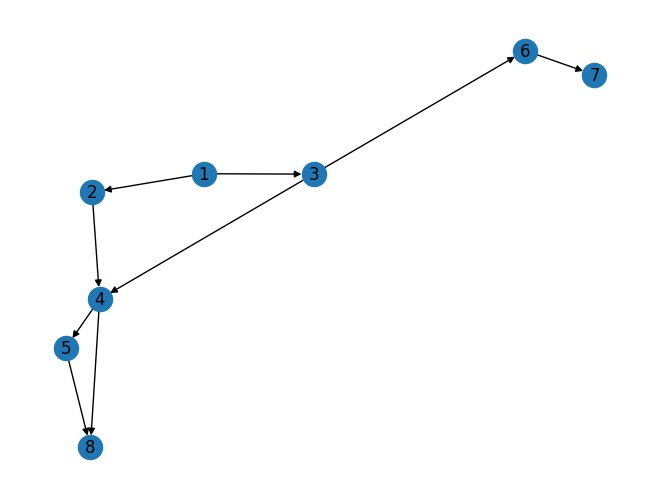

In [21]:
import matplotlib.pyplot as plt

nx.draw(sample_dag, with_labels=True)

In [22]:
partitions = PartitionTreeBuilder(sample_dag).build()

def dict_to_str(d, tabs=0):
  offset = '  '*tabs
  string = ""
  if isinstance(d, dict):
    string += "[\n"
    for k, v in d.items():
      string += f"{offset}{k}: {dict_to_str(v, tabs+1) if len(v) > 0 else None}\n"
    string += f"{offset}]"
    return string
  else:
    return d

print(dict_to_str(partitions))

[
frozenset({1, 2}): None
frozenset({3, 4, 5, 6, 7, 8}): [
  frozenset({8, 4, 5}): [
    frozenset({8, 5}): [
      frozenset({5}): None
      frozenset({8}): None
      ]
    frozenset({4}): None
    ]
  frozenset({3, 6, 7}): [
    frozenset({6}): None
    frozenset({7}): None
    ]
  ]
]


In [23]:
print(partitions)

{frozenset({1, 2}): {}, frozenset({3, 4, 5, 6, 7, 8}): {frozenset({8, 4, 5}): {frozenset({8, 5}): {frozenset({5}): {}, frozenset({8}): {}}, frozenset({4}): {}}, frozenset({3, 6, 7}): {frozenset({6}): {}, frozenset({7}): {}}}}


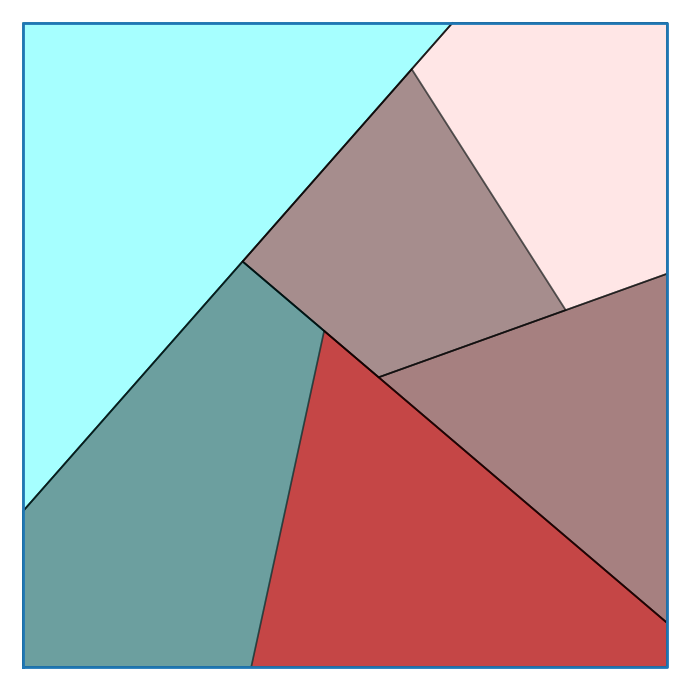

In [24]:
RecursivePowerDiagram(hierarchy=partitions).show()

# Testing pipeline with first few layers of WordNet

In [15]:
"""
Build a WordNet hyponym DAG in a NetworkX DiGraph, limited to the first N layers
starting from the synset 'entity.n.01'.

Requires: nltk, networkx
"""

from collections import deque
import nltk

nltk.download("Wordnet")

from nltk.corpus import wordnet as wn
import networkx as nx


def build_wordnet_hyponym_dag(
    root_synset_name: str = "entity.n.01",
    layers: int = 5,
    ensure_download: bool = True,
) -> nx.DiGraph:
    """
    Downloads WordNet (if requested), then builds a hyponym DAG from `root_synset_name`
    out to `layers` BFS layers (layer 0 = root).

    Nodes are synset names (e.g., "entity.n.01").
    Directed edges go parent -> hyponym.

    Returns:
        nx.DiGraph
    """
    if layers < 0:
        raise ValueError("layers must be >= 0")

    if ensure_download:
        # Download WordNet (and the Open Multilingual WordNet index; harmless if already present).
        nltk.download("wordnet", quiet=True)
        nltk.download("omw-1.4", quiet=True)

    root = wn.synset(root_synset_name)

    G = nx.DiGraph()
    G.add_node(root.name())

    # BFS by synset, tracking depth (layer)
    q = deque([(root, 0)])
    seen = {root.name()}

    while q:
        syn, depth = q.popleft()
        if depth >= layers:
            continue

        for child in syn.hyponyms():
            parent_name = syn.name()
            child_name = child.name()

            G.add_edge(parent_name, child_name)

            if child_name not in seen:
                seen.add(child_name)
                q.append((child, depth + 1))

    return G

[nltk_data] Error loading Wordnet: Package 'Wordnet' not found in
[nltk_data]     index


In [30]:
dag = build_wordnet_hyponym_dag(layers=7)
print(f"Nodes: {dag.number_of_nodes()}, Edges: {dag.number_of_edges()}")
# Example: show a few nodes
print("Sample nodes:", list(dag.nodes())[:10])

Nodes: 35348, Edges: 35826
Sample nodes: ['entity.n.01', 'thing.n.08', 'physical_entity.n.01', 'abstraction.n.06', 'stinker.n.02', 'change.n.06', 'pacifier.n.02', 'whacker.n.01', 'jimdandy.n.02', 'security_blanket.n.01']


In [31]:
wn_partitions = PartitionTreeBuilder(dag).build()

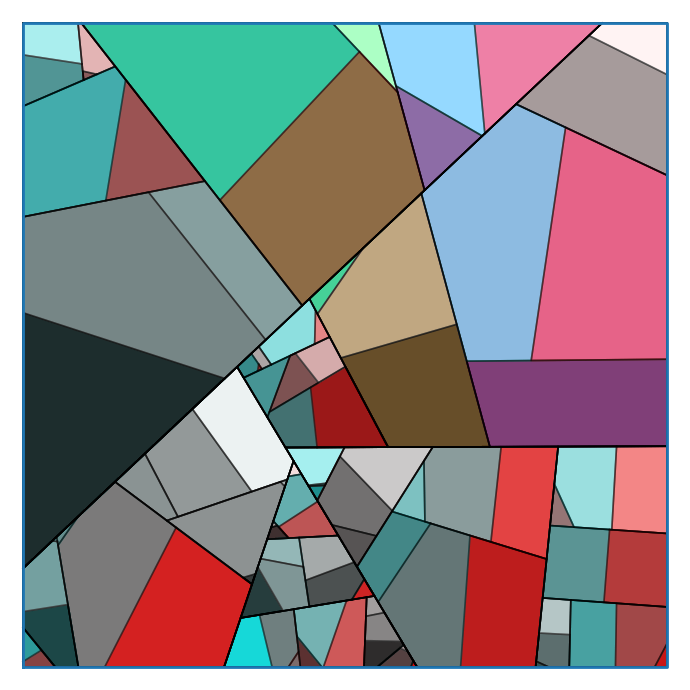

In [32]:
RecursivePowerDiagram(hierarchy=wn_partitions).show()